In [1]:
%pip install roboflow

  Using cached idna-3.7-py3-none-any.whl.metadata (9.9 kB)
  Using cached opencv_python_headless-4.10.0.84-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
Using cached idna-3.7-py3-none-any.whl (66 kB)
Using cached opencv_python_headless-4.10.0.84-cp37-abi3-win_amd64.whl (38.8 MB)
   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   --------------------- ------------------ 1.0/1.9 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 1.9/1.9 MB 4.5 MB/s  0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 4.2 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.9 MB 4.0 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.9 MB 3.9 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.9 MB 3.8 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 3.9 MB/s e

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\Users\\ASUS\\anaconda3\\envs\\yoloenv\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="mwBjiRfrEpCAczl3PDXS")
project = rf.workspace("vextors").project("food-oyviv-angmy")
version = project.version(1)
dataset = version.download("multiclass")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to food-1 in multiclass:: 100%|██████████| 3983/3983 [00:01<00:00, 3130.41it/s]


In [ ]:
dataset

In [ ]:
import glob

train_path = dataset.location + "/train"

images = glob.glob(train_path + "/**/*.jpg", recursive=True)

print(len(images))
print(images[:5])


2783
['/content/food-1/train/5ba431c5ef_jpg.rf.b83354c6829ba438c2969a692761b663.jpg', '/content/food-1/train/8ef9c0dff3_jpg.rf.407e62e4a092d2d26802a09082ea7638.jpg', '/content/food-1/train/015a02f670_jpg.rf.752fc6efc188ae4992d84a5ceea9d319.jpg', '/content/food-1/train/2ed8e49acf_jpg.rf.837cba602a159aac844c8bacb9680f85.jpg', '/content/food-1/train/4f50533a23_jpg.rf.c9b3fd16d607d422cacd0a6950aac924.jpg']


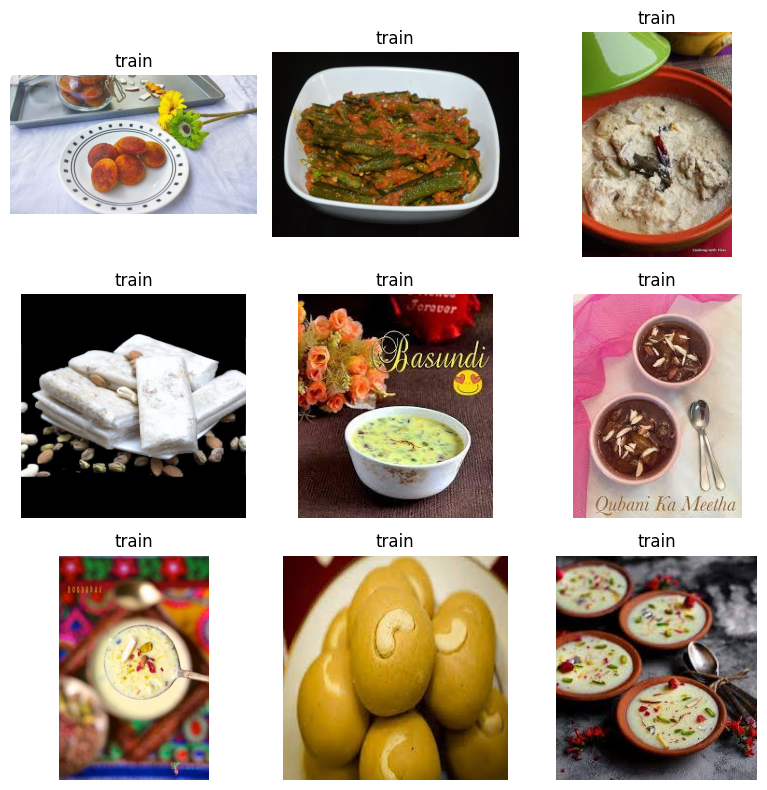

In [ ]:
import os
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image

# Get dataset path
data_path = dataset.location  # from Roboflow download

# Collect all training images (recursive search)
image_paths = glob.glob(os.path.join(data_path, "train", "**", "*.jpg"), recursive=True)
image_paths += glob.glob(os.path.join(data_path, "train", "**", "*.png"), recursive=True)

# Randomly select 9 images
sample_images = random.sample(image_paths, 9)

# Plot images in 3x3 grid
plt.figure(figsize=(8, 8))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")

    # Show class label (folder name)
    label = os.path.basename(os.path.dirname(img_path))
    plt.title(label)

plt.tight_layout()
plt.show()


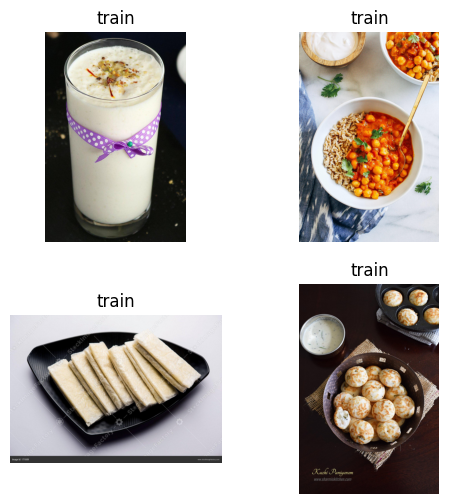

In [ ]:
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

images = glob.glob(os.path.join(dataset.location, "train", "**", "*.jpg"), recursive=True)

sample = random.sample(images, 4)

plt.figure(figsize=(6, 6))

for i, img_path in enumerate(sample):
    img = Image.open(img_path)

    # extract class name (parent folder)
    class_name = os.path.basename(os.path.dirname(img_path))

    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()


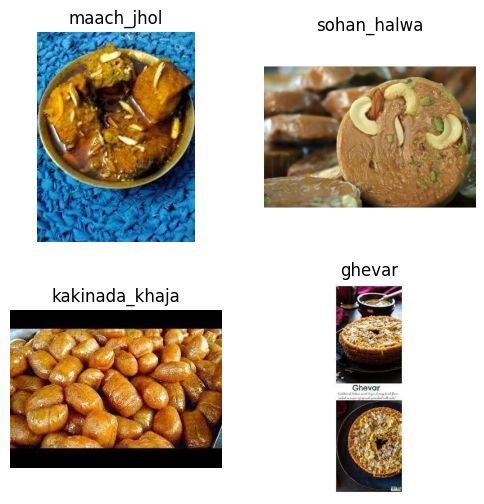

In [ ]:
import pandas as pd
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# load CSV
csv_path = os.path.join(dataset.location, "train", "_classes.csv")
df = pd.read_csv(csv_path)

# pick 4 random rows
sample = df.sample(4)

plt.figure(figsize=(6, 6))

for i, row in enumerate(sample.itertuples(index=False)):
    filename = row[0]  # first column = filename

    # find class (column where value = 1)
    class_idx = list(row[1:]).index(1)
    class_name = df.columns[1:][class_idx]

    # load image
    img_path = os.path.join(dataset.location, "train", filename)
    img = Image.open(img_path)

    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()


In [ ]:
import torchvision.transforms as transforms
import torchvision.transforms.functional as F

class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = max(w, h)
        hp = (max_wh - w) // 2
        vp = (max_wh - h) // 2
        padding = (hp, vp, max_wh - w - hp, max_wh - h - vp)
        return F.pad(image, padding, 0, "constant")

transform = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),  # required for pretrained models
    transforms.ToTensor(),
])


In [ ]:
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image
import os
import torch

class FoodDataset(Dataset):
    def __init__(self, root, split="train", transform=None):
        self.root = os.path.join(root, split)
        self.df = pd.read_csv(os.path.join(self.root, "_classes.csv"))
        self.transform = transform

        self.class_names = list(self.df.columns[1:])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.root, row["filename"])
        image = Image.open(img_path).convert("RGB")

        label_vec = row[1:].astype(int).values
        label = torch.tensor(label_vec).argmax().long()

        if self.transform:
            image = self.transform(image)

        return image, label



In [ ]:
from torch.utils.data import DataLoader

train_ds = FoodDataset(dataset.location, "train", transform)
val_ds = FoodDataset(dataset.location, "valid", transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)


In [ ]:
import torchvision.models as models
import torch.nn as nn

num_classes = len(train_ds.class_names)

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, num_classes)


In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True


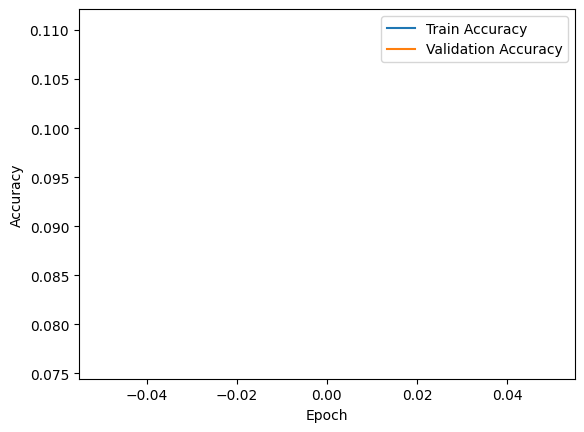

Epoch 1: Train Acc = 0.0762, Val Acc = 0.1104
Epoch 2: Train Acc = 0.2921, Val Acc = 0.2045
Epoch 3: Train Acc = 0.4398, Val Acc = 0.2384
Epoch 4: Train Acc = 0.5340, Val Acc = 0.2886
Epoch 5: Train Acc = 0.6148, Val Acc = 0.3438
Epoch 6: Train Acc = 0.6734, Val Acc = 0.3764
Epoch 7: Train Acc = 0.7463, Val Acc = 0.4103
Epoch 8: Train Acc = 0.7776, Val Acc = 0.3864


KeyboardInterrupt: 

In [ ]:
import os
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
import torchvision.models as models

# -----------------------------
# Padding transform (no cropping)
# -----------------------------
class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = max(w, h)
        hp = (max_wh - w) // 2
        vp = (max_wh - h) // 2
        padding = (hp, vp, max_wh - w - hp, max_wh - h - vp)
        return F.pad(image, padding, 0, "constant")


# -----------------------------
# Transforms
# -----------------------------
train_transform = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.RandomPerspective(distortion_scale=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


# -----------------------------
# Dataset loader (CSV-based)
# -----------------------------
class FoodDataset(Dataset):
    def __init__(self, root, split, transform=None):
        self.root = os.path.join(root, split)
        self.df = pd.read_csv(os.path.join(self.root, "_classes.csv"))
        self.transform = transform
        self.class_names = list(self.df.columns[1:])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.root, row["filename"])
        image = Image.open(img_path).convert("RGB")

        label_vec = row[1:].astype(int).values
        label = torch.tensor(label_vec).argmax().long()

        if self.transform:
            image = self.transform(image)

        return image, label


# -----------------------------
# Load datasets
# -----------------------------
train_ds = FoodDataset(dataset.location, "train", train_transform)
val_ds = FoodDataset(dataset.location, "valid", val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

num_classes = len(train_ds.class_names)


# -----------------------------
# Model (ResNet-18)
# -----------------------------
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, num_classes)
)



# -----------------------------
# Training setup
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)


# -----------------------------
# Live accuracy plot
# -----------------------------
train_acc_history = []
val_acc_history = []

plt.ion()
fig, ax = plt.subplots()


# -----------------------------
# Training loop
# -----------------------------
epochs = 10

for epoch in range(epochs):

    # ---- TRAIN ----
    model.train()
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total


    # ---- VALIDATION ----
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total


    # ---- Plot update ----
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    ax.clear()
    ax.plot(train_acc_history, label="Train Accuracy")
    ax.plot(val_acc_history, label="Validation Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    plt.pause(0.01)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")


plt.ioff()
plt.show()


In [ ]:
2extra_epochs = 30
start_epoch = len(train_acc_history)

for epoch in range(start_epoch, start_epoch + extra_epochs):

    # ---- TRAIN ----
    model.train()
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total


    # ---- VALIDATION ----
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total


    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    ax.clear()
    ax.plot(train_acc_history, label="Train Accuracy")
    ax.plot(val_acc_history, label="Validation Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    plt.pause(0.01)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")


Epoch 11: Train Acc = 0.3618, Val Acc = 0.2597
Epoch 12: Train Acc = 0.3820, Val Acc = 0.2685
Epoch 13: Train Acc = 0.4125, Val Acc = 0.2811
Epoch 14: Train Acc = 0.4193, Val Acc = 0.2986
Epoch 15: Train Acc = 0.4330, Val Acc = 0.2911
Epoch 16: Train Acc = 0.4520, Val Acc = 0.2986
Epoch 17: Train Acc = 0.4668, Val Acc = 0.3149
Epoch 18: Train Acc = 0.4603, Val Acc = 0.3300
Epoch 19: Train Acc = 0.4865, Val Acc = 0.3237
Epoch 20: Train Acc = 0.4912, Val Acc = 0.3388
Epoch 21: Train Acc = 0.5092, Val Acc = 0.3350
Epoch 22: Train Acc = 0.5243, Val Acc = 0.3450
Epoch 23: Train Acc = 0.5293, Val Acc = 0.3513
Epoch 24: Train Acc = 0.5271, Val Acc = 0.3501
Epoch 25: Train Acc = 0.5469, Val Acc = 0.3576
Epoch 26: Train Acc = 0.5494, Val Acc = 0.3551
Epoch 27: Train Acc = 0.5555, Val Acc = 0.3676
Epoch 28: Train Acc = 0.5584, Val Acc = 0.3614
Epoch 29: Train Acc = 0.5645, Val Acc = 0.3689
Epoch 30: Train Acc = 0.5720, Val Acc = 0.3676
Epoch 31: Train Acc = 0.5796, Val Acc = 0.3902
Epoch 32: Tra

In [ ]:

# =============================
# 1. Imports
# =============================
import os
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# =============================
# 2. Paths
# =============================
data_path = dataset.location

train_csv = os.path.join(data_path, "train", "_classes.csv")
val_csv = os.path.join(data_path, "valid", "_classes.csv")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)

class_names = train_df.columns[1:]
num_classes = len(class_names)

print("Classes:", num_classes)

# =============================
# 3. Image loader (padding, not cropping)
# =============================
IMG_SIZE = 224

def load_image(row, folder):

    filename = row[0]
    label = tf.argmax(row[1:])

    img_path = os.path.join(folder, filename)

    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)

    # pad to square
    h = tf.shape(img)[0]
    w = tf.shape(img)[1]
    max_dim = tf.maximum(h, w)

    img = tf.image.resize_with_pad(img, max_dim, max_dim)

    # resize to model size
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    # ResNet preprocessing
    img = tf.keras.applications.resnet.preprocess_input(img)

    return img, label

# =============================
# 4. tf.data pipelines
# =============================
BATCH_SIZE = 32

def make_dataset(df, folder, training=True):

    ds = tf.data.Dataset.from_tensor_slices(df.values)

    ds = ds.map(
        lambda row: load_image(row, folder),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(1000)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = make_dataset(train_df, os.path.join(data_path, "train"), True)
val_ds = make_dataset(val_df, os.path.join(data_path, "valid"), False)

# =============================
# 5. Model (ResNet50 fine-tuning)
# =============================
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

# =============================
# 6. Compile
# =============================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =============================
# 7. Train
# =============================
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# =============================
# 8. Plot accuracy
# =============================
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")

plt.show()

Classes: 80


ValueError: Failed to convert a NumPy array to a Tensor (Unsupported object type int).

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 112MB/s] 


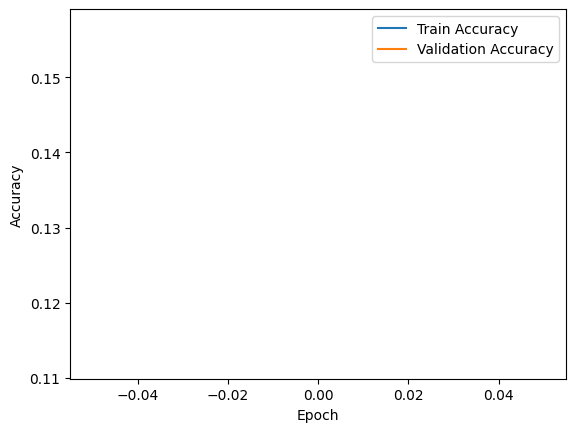

[MobileNet] Epoch 1: Train = 0.1121, Val = 0.1568
[MobileNet] Epoch 2: Train = 0.3611, Val = 0.2886
[MobileNet] Epoch 3: Train = 0.4912, Val = 0.3187
[MobileNet] Epoch 4: Train = 0.5803, Val = 0.3526
[MobileNet] Epoch 5: Train = 0.6299, Val = 0.3701
[MobileNet] Epoch 6: Train = 0.7183, Val = 0.3777
[MobileNet] Epoch 7: Train = 0.7463, Val = 0.3827
[MobileNet] Epoch 8: Train = 0.7718, Val = 0.3488
[MobileNet] Epoch 9: Train = 0.8196, Val = 0.4115
[MobileNet] Epoch 10: Train = 0.8444, Val = 0.4316


In [ ]:
# -----------------------------
# Second model (MobileNetV2)
# -----------------------------
model2 = models.mobilenet_v2(weights="IMAGENET1K_V1")

# replace classifier
model2.classifier[1] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model2.last_channel, num_classes)
)

# full fine-tuning
for param in model2.parameters():
    param.requires_grad = True

model2.to(device)

optimizer2 = torch.optim.Adam(model2.parameters(), lr=3e-4, weight_decay=1e-4)

train_acc_history2 = []
val_acc_history2 = []

plt.ion()
fig2, ax2 = plt.subplots()

epochs2 = 10

for epoch in range(epochs2):

    # ---- TRAIN ----
    model2.train()
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model2(images)
        loss = criterion(outputs, labels)

        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total


    # ---- VALIDATION ----
    model2.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model2(images)
            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total


    train_acc_history2.append(train_acc)
    val_acc_history2.append(val_acc)

    ax2.clear()
    ax2.plot(train_acc_history2, label="Train Accuracy")
    ax2.plot(val_acc_history2, label="Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    plt.pause(0.01)

    print(f"[MobileNet] Epoch {epoch+1}: Train = {train_acc:.4f}, Val = {val_acc:.4f}")

plt.ioff()
plt.show()


In [ ]:
epochs3 = 10

for epoch in range(epochs3):

    # ---- TRAIN ----
    model2.train()
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model2(images)
        loss = criterion(outputs, labels)

        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total


    # ---- VALIDATION ----
    model2.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model2(images)
            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total


    train_acc_history2.append(train_acc)
    val_acc_history2.append(val_acc)

    ax2.clear()
    ax2.plot(train_acc_history2, label="Train Accuracy")
    ax2.plot(val_acc_history2, label="Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    plt.pause(0.01)

    print(f"[Model 2] Epoch {epochs2+epoch+1}: Train = {train_acc:.4f}, Val = {val_acc:.4f}")

plt.ioff()
plt.show()

[Model 2] Epoch 11: Train = 0.9831, Val = 0.5232
[Model 2] Epoch 12: Train = 0.9817, Val = 0.5257


KeyboardInterrupt: 

In [ ]:
# -----------------------------
# Second model (full fine-tuning)
# -----------------------------
model2 = models.resnet18(weights="IMAGENET1K_V1")
model2.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model2.fc.in_features, num_classes)
)


# DO NOT freeze anything
for param in model2.parameters():
    param.requires_grad = True

model2.to(device)

optimizer2 = torch.optim.Adam(model2.parameters(), lr=3e-4, weight_decay=1e-4)

train_acc_history2 = []
val_acc_history2 = []

plt.ion()
fig2, ax2 = plt.subplots()

epochs2 = 10

for epoch in range(epochs2):

    # ---- TRAIN ----
    model2.train()
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model2(images)
        loss = criterion(outputs, labels)

        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total


    # ---- VALIDATION ----
    model2.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model2(images)
            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total


    train_acc_history2.append(train_acc)
    val_acc_history2.append(val_acc)

    ax2.clear()
    ax2.plot(train_acc_history2, label="Train Accuracy")
    ax2.plot(val_acc_history2, label="Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    plt.pause(0.01)

    print(f"[Model 2] Epoch {epoch+1}: Train = {train_acc:.4f}, Val = {val_acc:.4f}")

plt.ioff()
plt.show()
